In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA

In [6]:
d = pd.read_csv("insurance.csv")
df = d[["age","bmi"]]
df.head()

,age,bmi
0,19,27.900
1,18,33.770
2,28,33.000
3,33,22.705
4,32,28.880


In [7]:
scaler = StandardScaler()
X_scaler = scaler.fit_transform(df)
X_scaler = pd.DataFrame(X_scaler,columns=["age","bmi"])
X_scaler.head()

,age,bmi
0,-1.438764,-0.453320
1,-1.509965,0.509621
2,-0.797954,0.383307
3,-0.441948,-1.305531
4,-0.513149,-0.292556


In [8]:
inet = []
for i in range(1,26):
    K_Means = KMeans(n_clusters=i,random_state=42)
    K_Means.fit(X_scaler)
    inet.append(K_Means.inertia_)
inet

[2676.0,
 1631.867162594892,
 1142.0670362997346,
 785.9004652064643,
 679.5595578371542,
 552.3038736269518,
 460.77193904606924,
 404.6935606760155,
 365.6960433890299,
 335.1808561283224,
 316.0873529101656,
 282.37345994113014,
 265.5723189894831,
 238.22997358089722,
 222.80311938143316,
 206.15753940092654,
 189.47180281555438,
 179.39655407796374,
 172.99988034664696,
 163.93604231421378,
 161.56127365290683,
 152.62622998929686,
 140.79663428598704,
 137.52085045934507,
 134.008084314344]

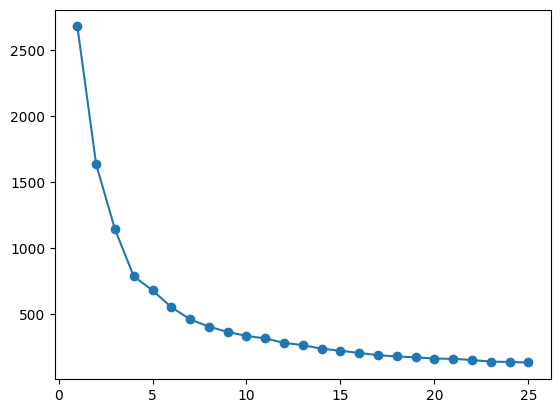

In [9]:
plt.plot(range(1,26),inet,marker = "o")
plt.show()

In [10]:
K_Means_fin = KMeans(n_clusters=i,random_state=42)
cluster_labels = K_Means_fin.fit_predict(X_scaler)
cluster_labels

array([20,  2, 16, ...,  6, 20,  3], shape=(1338,), dtype=int32)

In [11]:
df["cluster"] = cluster_labels
df.head()

C:\Users\Amir sohail\AppData\Local\Temp\ipykernel_10092\418670468.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["cluster"] = cluster_labels


,age,bmi,cluster
0,19,27.900,20
1,18,33.770,2
2,28,33.000,16
3,33,22.705,19
4,32,28.880,23


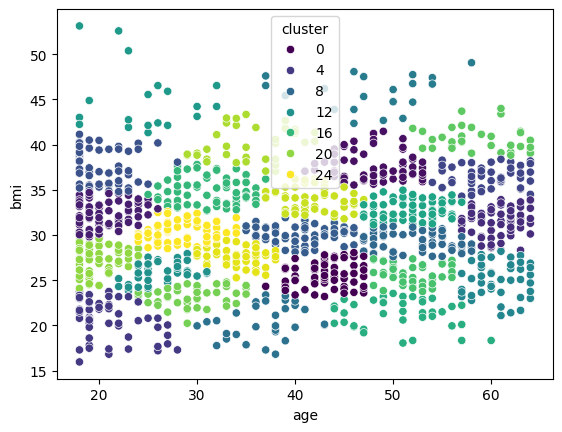

In [12]:
sns.scatterplot(data=df,x="age",y="bmi",hue="cluster",palette="viridis")
plt.show()

In [13]:
dbscan = DBSCAN(eps=3,min_samples=5)
labels = dbscan.fit_predict(df)
df["label"] = labels
df.head()

C:\Users\Amir sohail\AppData\Local\Temp\ipykernel_10092\3451953245.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"] = labels


,age,bmi,cluster,label
0,19,27.900,20,0
1,18,33.770,2,1
2,28,33.000,16,2
3,33,22.705,19,3
4,32,28.880,23,4


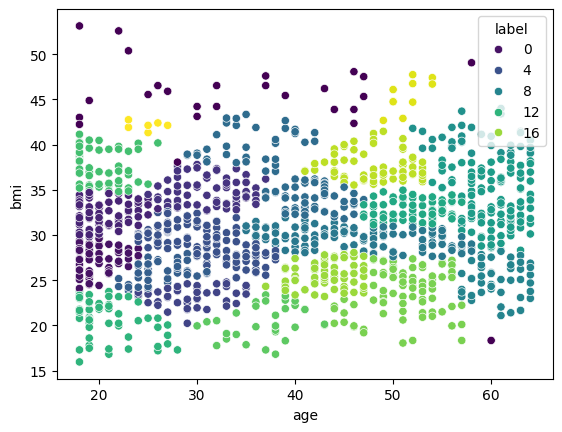

In [14]:
sns.scatterplot(data=df,x="age",y="bmi",hue="label",palette="viridis")
plt.show()

In [15]:
X,y = make_blobs(n_samples=500,n_features=5,centers=3,cluster_std=1.5,random_state=42)
X

array([[ -9.85712583,   9.52196609,   6.40680626,  -6.81757623,
         -7.86054541],
       [ -8.04717781,   8.40261648,   6.40946097,  -4.33576029,
         -6.70289196],
       [ -3.73690895,   6.7601386 ,   4.24877609,   0.28504117,
         -7.10318219],
       ...,
       [ -5.82805   ,  -7.29173339,   7.48633693,   2.71623974,
          7.33823548],
       [ -2.48648271,   9.67739715,   6.21190845,   1.03031506,
         -7.54637531],
       [ -8.63901448, -10.68852991,   8.36601977,   4.94211449,
          3.77070371]], shape=(500, 5))

In [16]:
x_scaler = scaler.fit_transform(X)
x_scaler

array([[-1.07039133,  0.74546814,  0.0859273 , -1.58466105, -0.90798501],
       [-0.52251206,  0.61451192,  0.08731966, -0.95761934, -0.68801347],
       [ 0.78222538,  0.4223533 , -1.04593191,  0.20984645, -0.76407462],
       ...,
       [ 0.14922774, -1.22161917,  0.65212732,  0.82409945,  1.98001159],
       [ 1.16073493,  0.7636525 , -0.01629411,  0.39814317, -0.84828797],
       [-0.70166364, -1.61902103,  1.11350971,  1.38647649,  1.30212699]],
      shape=(500, 5))

In [18]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaler)
x_pca

array([[ 1.40522818e+00, -1.73079914e+00],
       [ 1.03463536e+00, -9.82792414e-01],
       [ 1.10182830e+00,  1.09084050e+00],
       [-1.76465839e+00,  1.09970698e-01],
       [ 8.59673831e-01, -1.63970361e+00],
       [ 1.09738958e+00,  1.11937509e+00],
       [ 1.04453451e+00,  1.88953610e+00],
       [-3.14810185e+00, -1.06909853e-01],
       [-1.34287183e+00,  7.48033000e-01],
       [ 4.59419122e-01,  9.66806100e-01],
       [ 1.64897776e+00,  1.95384681e+00],
       [ 7.73369393e-01,  2.09584610e+00],
       [-1.92869648e+00,  9.48608771e-02],
       [ 1.15480661e+00, -1.42564791e+00],
       [ 7.07330515e-01, -1.01056640e+00],
       [ 1.59661674e+00, -1.64931961e+00],
       [-2.40550592e+00, -7.53357753e-01],
       [-1.97627695e+00, -3.59747020e-02],
       [ 1.26193015e+00,  2.72813008e+00],
       [ 1.58339885e+00, -1.46125327e+00],
       [ 1.61435981e+00,  1.29812279e+00],
       [-1.74438705e+00,  1.58820049e-01],
       [-1.88938008e+00,  3.66662930e-01],
       [ 6.

In [19]:
df_pca = pd.DataFrame(x_pca,columns=["PCA1","PCA2"])
df_pca["labels"] = y
df_pca.head()

,PCA1,PCA2,labels
0,1.405228,-1.730799,2
1,1.034635,-0.982792,2
2,1.101828,1.090840,0
3,-1.764658,0.109971,1
4,0.859674,-1.639704,2


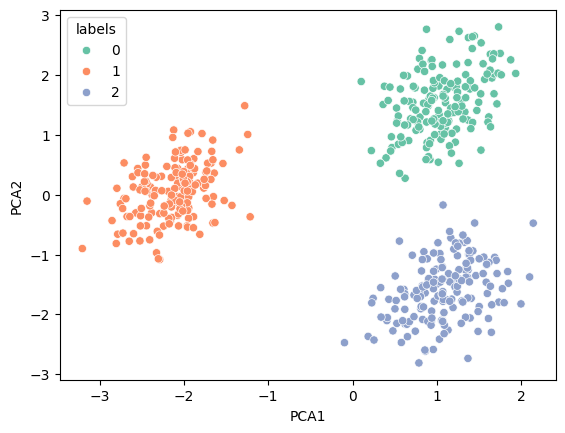

In [21]:
sns.scatterplot(data=df_pca,x="PCA1",y="PCA2",hue="labels",palette="Set2")
plt.show()